# Data Viewer

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

## Acoustic Data

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
from tritonoa.data.reader import read_hdf5, read_inventory
from tritonoa.data.time import TIME_PRECISION

from vineyard.config import get_path
from vineyard.plotting import plot_spectrogram

2025-07-01 07:11:05.732|INFO|NumExpr defaulting to 14 threads.


In [3]:
# sensor = "3dvha"
# time_start = np.datetime64("2023-12-01T21:44:00.00", TIME_PRECISION)
# time_end = np.datetime64("2023-12-01T22:52:00.00", TIME_PRECISION)
# # time_start = np.datetime64("2023-12-01T22:25:00.00", TIME_PRECISION)
# # time_end = np.datetime64("2023-12-01T22:26:00.00", TIME_PRECISION)
# channels = 7

sensor = "vla1"
time_start = np.datetime64("2023-12-01T21:51:00.00", TIME_PRECISION)
time_end = np.datetime64("2023-12-01T21:52:00.00", TIME_PRECISION)
channels = 3

# sensor = "vla2"
# time_start = np.datetime64("2023-12-01T22:25:00.00", TIME_PRECISION)
# time_end = np.datetime64("2023-12-01T22:28:00.00", TIME_PRECISION)
# channels = 0

inventory = get_path(f"{sensor}_inventory")

ds = read_inventory(
    inventory,
    time_start=time_start,
    time_end=time_end,
    channels=channels,
).decimate(40).filter("bandpass", [15.0, 30.0])
print(ds.stats.sampling_rate)



nperseg = 1024
hop = 4
nfft = 2 ** 14
fs = ds.stats.sampling_rate
channels = np.arange(ds.num_channels)
window = signal.windows.hann(nperseg)
STFT = signal.ShortTimeFFT(window, hop, fs, mfft=nfft, scale_to="psd")
Sxx = STFT.spectrogram(ds.data[0])
f = STFT.f
t = STFT.t(ds.num_samples)
tvec = time_start + np.array([np.timedelta64(int(time * 1e6), TIME_PRECISION) for time in t])

488.28125


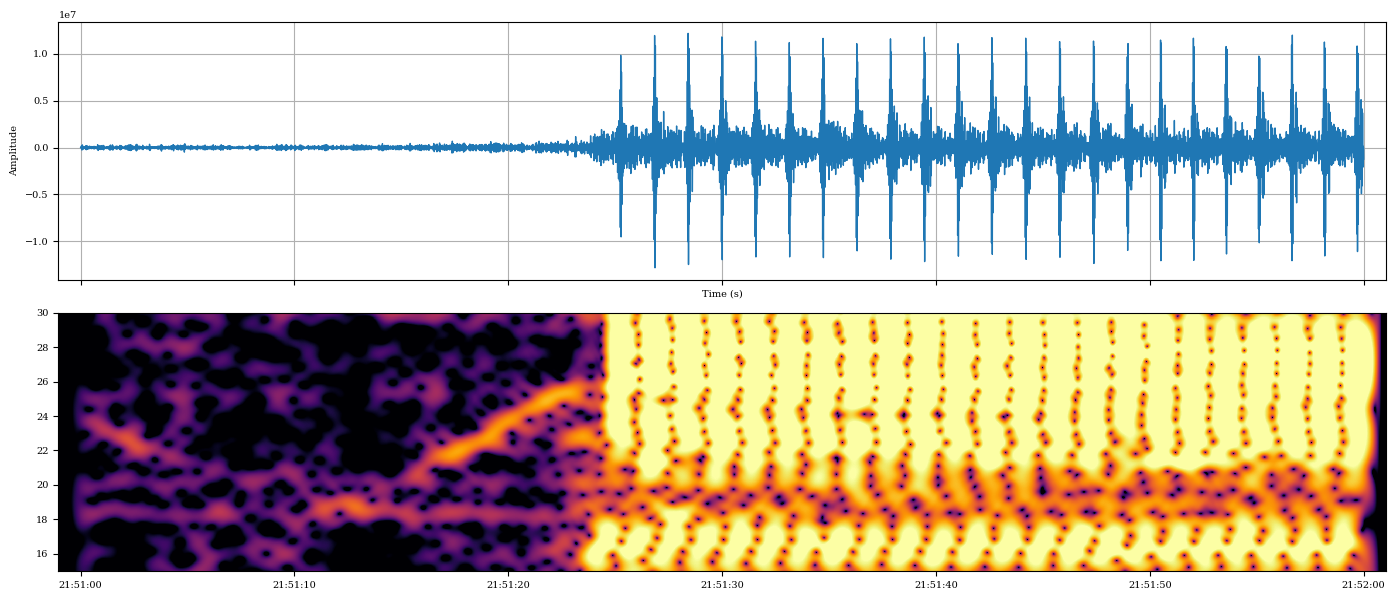

In [4]:
fig, axes = plt.subplots(nrows=2, figsize=(14, 6), sharex=True)
ax = axes[0]
ax.plot(ds.time_vector, ds.data[0], label="Original Signal")
ax.grid()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")

ax = axes[1]
plot_spectrogram(f, tvec, Sxx, ax=ax, vmin=80, vmax=110)
ax.set_ylim(15, 30)
plt.tight_layout()
plt.show()

In [9]:
ds_synth = read_hdf5("data/acoustic/vla1_synthetic_strikes.hdf5")

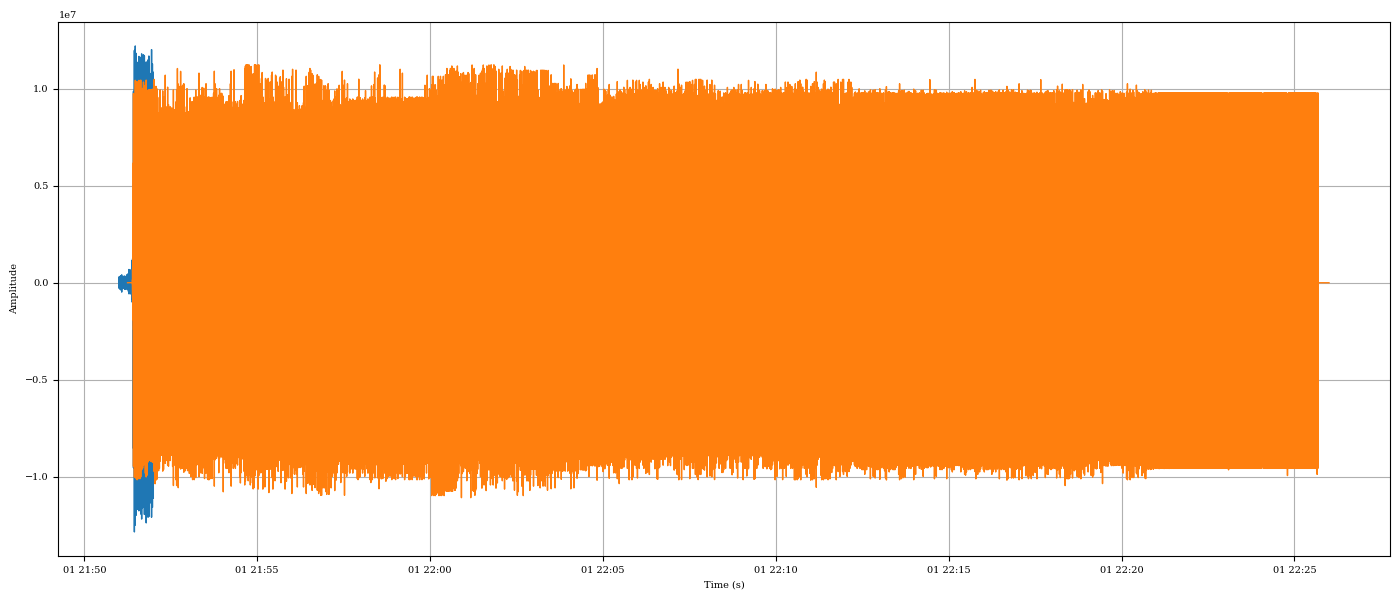

In [10]:
synth_data = ds_synth.data[0]
synth_t = ds_synth.time_vector

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ds.time_vector, ds.data[0], label="Original Signal")
ax.plot(synth_t, synth_data, label="Synthetic Strikes")
ax.grid()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

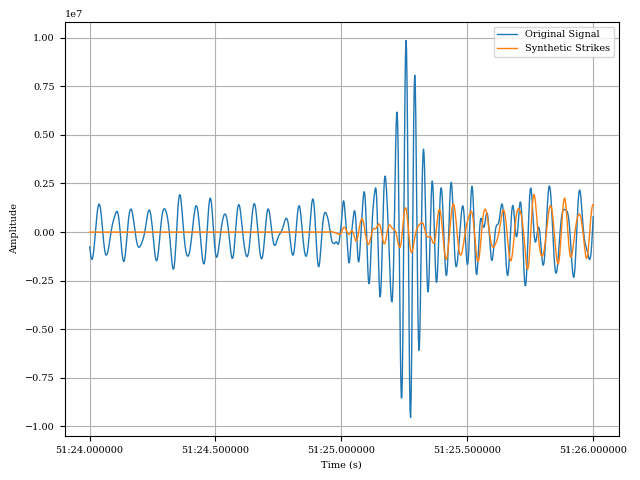

In [7]:
starttime=np.datetime64("2023-12-01T21:51:24", TIME_PRECISION)
endtime=np.datetime64("2023-12-01T21:51:26", TIME_PRECISION)
ds_single = ds.copy().trim(starttime=starttime, endtime=endtime)
ds_synth_single = ds_synth.copy().trim(starttime=starttime, endtime=endtime)

plt.figure()
plt.plot(ds_single.time_vector, ds_single.data[0], label="Original Signal")
plt.plot(ds_synth_single.time_vector, ds_synth_single.data[0], label="Synthetic Strikes")
# plt.plot(ds_single.data[0], label="Original Signal")
# plt.plot(ds_synth_single.data[0], label="Synthetic Strikes")
plt.grid()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()


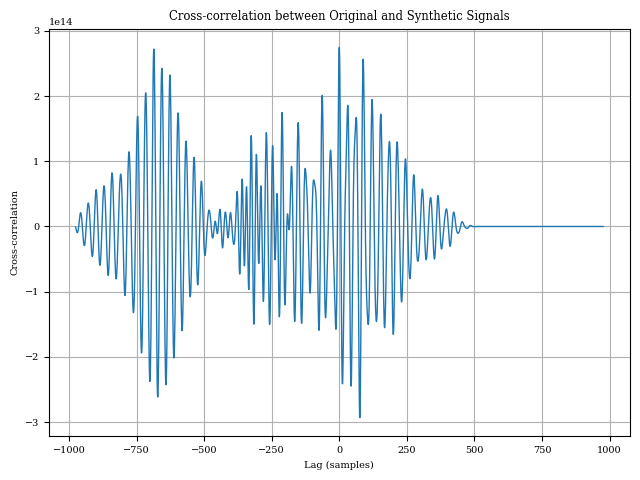

In [8]:
xcorr = signal.correlate(ds_single.data[0], ds_synth_single.data[0], mode="full")
lags = signal.correlation_lags(ds_single.num_samples, ds_synth_single.num_samples, mode="full")

plt.figure()
plt.plot(lags, xcorr)
plt.xlabel("Lag (samples)")
plt.ylabel("Cross-correlation")
plt.title("Cross-correlation between Original and Synthetic Signals")
plt.grid()
plt.tight_layout()
plt.show()